# Test linear model on all Time Series

In [4]:
from astropy.io import fits
from scipy.io import readsav
import numpy as np
import matplotlib.pyplot as plt

import torch  # to load PCA data

from tqdm import tqdm

import tools as t

## Load data

In [5]:
# loading spectra and time
path_data = '../data/sim_series/'  # directory where the files are saved
TS = 20  # time series used
data_spectra = []
for i in range(TS):  # files have the same name, only number changes
    data_spectra.append(fits.getdata(path_data + f'flux_norm_6173_lionel_tau1_spatialscaling1_sansrotation_serie{i}.fits'))
data_spectra = np.array(data_spectra)

times = np.arange(0, len(data_spectra[0]) * 144, 144) / 60 / 24  # time in days, same for all time series

In [6]:
# Loading PCA scores and RVs for each TS
# Parameters

N = 3686  # timesteps
M = 20  # PCs

# Load data

scores = []
rv = []

for i in tqdm(range(TS)):

    scores_i = []
    rv_i = []
    
    for j in range(N):
        
        data = torch.load(f'../data/PCA/TS{i+1}/t_{j}.pt')

        scores_i.append(data['scores'].float())
        rv_i.append(torch.as_tensor(data['rv'], dtype=torch.float32))

    scores.append(np.array(
        torch.stack(scores_i)
        ))
    rv.append(np.array(
        torch.stack(rv_i)
        ))

scores = np.array(scores)
rv = np.array(rv)

print("Total X shape:", scores.shape)
print("Total y shape:", rv.shape)

  0%|          | 0/20 [00:00<?, ?it/s]/tmp/ipykernel_188109/2903247742.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{i+1}/t_{j}.pt'

Total X shape: (20, 3686, 20)
Total y shape: (20, 3686)


## Train using TS1

In [7]:
# do a linear model (y = I * X) to compare with the result from the neural network

# get the scores and RVs from the first TS
scores_0 = scores[0]
rv_true_0 = rv[0]

k = 20  # number of PCs used for the fit
scores_matrix_0 = np.array(scores_0)[:, :k]  # this is I in the linear fit, a matrix whose columns are the scores of the first k principal components

train_size = int(0.7 * N)

# separate the scores and RVs into sub samples
scores_train_0 = scores_matrix_0[:train_size]
scores_test_0  = scores_matrix_0[train_size:]

rv_true_train_0 = rv_true_0[:train_size]
rv_true_test_0 = rv_true_0[train_size:]

times_test = times[train_size:]

# training the linear model using all the scores

G = np.dot(scores_train_0.T, scores_train_0)
b = np.dot(scores_train_0.T, rv_true_train_0)
alpha = np.linalg.solve(G, b)

In [8]:
# testing the model on the same TS
rv_pred_test_0  = np.dot(alpha, scores_test_0.T)  # predict
res_test_linear_0  = rv_true_test_0 - rv_pred_test_0  # calculate residuals
std_res_linear_0 = np.std(res_test_linear_0)

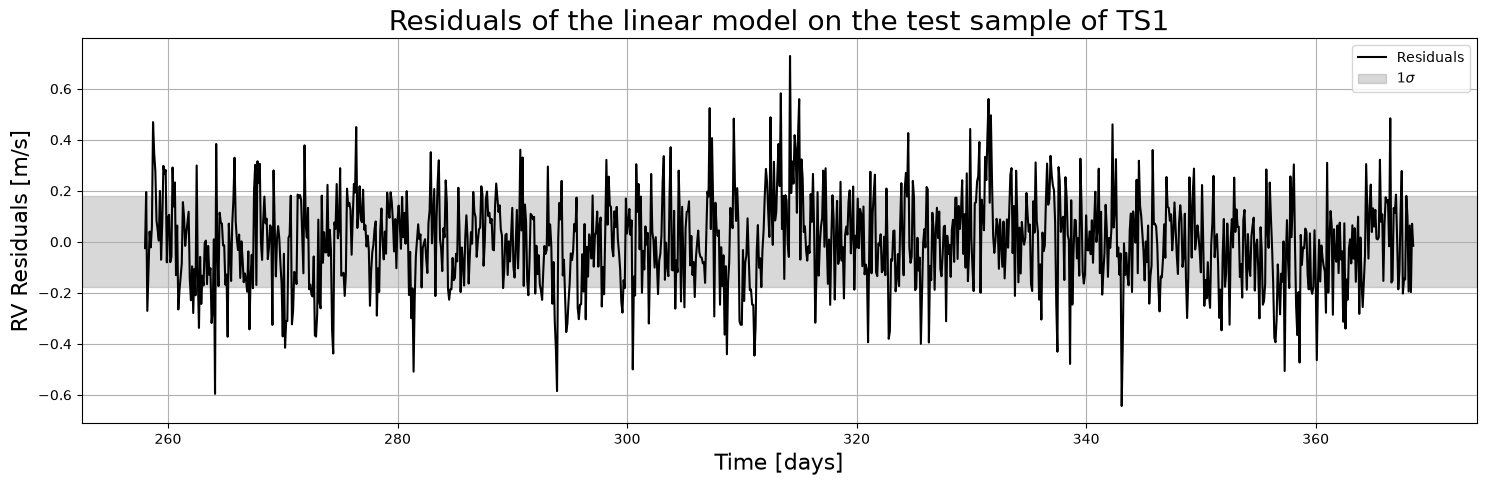

In [9]:
fig, ax = plt.subplots(figsize=(18, 5))
ax.set_title('Residuals of the linear model on the test sample of TS1', size=20)

ax.grid()
ax.plot(times_test, res_test_linear_0, color='k', label='Residuals')
ax.axhspan(-std_res_linear_0, std_res_linear_0, color='gray', alpha=.3, label=r'$1\sigma$')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV Residuals [m/s]', size=16)
ax.legend()

plt.show()

In [10]:
print(f'The standard deviation of the residuals is {std_res_linear_0:.2f} m/s.')

The standard deviation of the residuals is 0.18 m/s.


## Testing the model on the other TS

In [11]:
chunk_size = 21  # use chunks to get error bars

rv_pred = []
res = []
res_sigma = []


for i in range(TS):  # iterate over TS

    scores_i = scores[i]
    rv_true_i = rv[i]

    rv_pred_i = []  # list of chunks of predicted RV
    res_i = []  # list of chunks of residuals calculated from rv_pred_i
    res_sigma_i = []  # list of numbers: std of each chunk in res_i

    j = 0

    while j < N:  # iterate on chunks

        if j + chunk_size > N:  # last elements of the TS not included if (N % chunk_size != 0)
            break

        else:
            scores_j = scores_i[j:j+chunk_size]  # scores of shape chunk_size x PCs
            rv_true_j = rv_true_i[j:j+chunk_size]  # chunk_size values of RV

            rv_pred_j = np.dot(alpha, scores_j.T)  # predict chunk_size values of RV
            res_j = rv_true_j - rv_pred_j  # chunk residuals
            
            rv_pred_i.append(rv_pred_j)        # append chunk of resulting RV to a list
            res_i.append(res_j)                # append residuals of each chunk
            res_sigma_i.append(np.std(res_j))  # append std of res_j
        
        j += chunk_size

    rv_pred.append(np.array(rv_pred_i))
    res.append(np.array(res_i))
    res_sigma.append(np.array(res_sigma_i))

rv_pred = np.array(rv_pred)
res = np.array(res)
res_sigma = np.array(res_sigma)

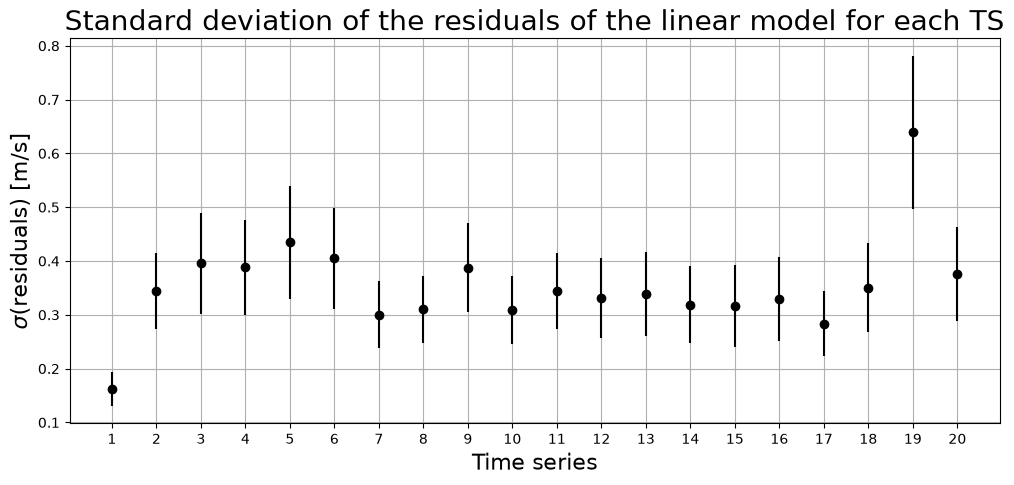

In [12]:
# show std for each TS
ts_arr = np.linspace(1, TS, TS)

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Standard deviation of the residuals of the linear model for each TS', size=20)

ax.grid()
ax.errorbar(ts_arr, np.mean(res_sigma, axis=1), np.std(res_sigma, axis=1), fmt='o', color='k', zorder=2)  # PUT ERRORBARS!

ax.set_xlabel('Time series', size=16)
ax.set_ylabel(r'$\sigma$(residuals) [m/s]', size=16)

ax.set_xticks(ts_arr)

plt.show()

Error bars: there are parts (chunks) of the RV series that are better predicted than others.

The points show the mean of the standard deviation of the residuals over all the chunks of a series.

The error bars show the standard deviation of the std of the residuals in each chunk.

In each TS, we have:

- Predictions: 175 chunks of size 21.

- Residuals: 175 chunks of size 21.

- Standard deviation of the residuals: 175 values (one for each chunk).

- Mean of the standard deviation of the residuals: 1 value (shown as points in the plot).

- Standard deviation of the standard deviation of the residuals: 1 value (shown as error bars in the plot).

In [20]:
print('---------- Stats of the points from the plot above ----------')
print(f'Mean:   {np.mean(np.mean(res_sigma, axis=1)):.2f} m/s.')
print(f'Median: {np.median(np.mean(res_sigma, axis=1)):.2f} m/s.')
print(f'Std:    {np.std(np.mean(res_sigma, axis=1)):.2f} m/s.')
print('\nOver all TS, the standard deviation of the residuals is '
      f'{np.mean(np.mean(res_sigma, axis=1)):.2f} '
      f'+- {np.std(np.mean(res_sigma, axis=1)):.2f} m/s.')

---------- Stats of the points from the plot above ----------
Mean:   0.35 m/s.
Median: 0.34 m/s.
Std:    0.09 m/s.

Over all TS, the standard deviation of the residuals is 0.35 +- 0.09 m/s.


In [21]:
chunks_rest = N % chunk_size
times_short = times[:-chunks_rest]

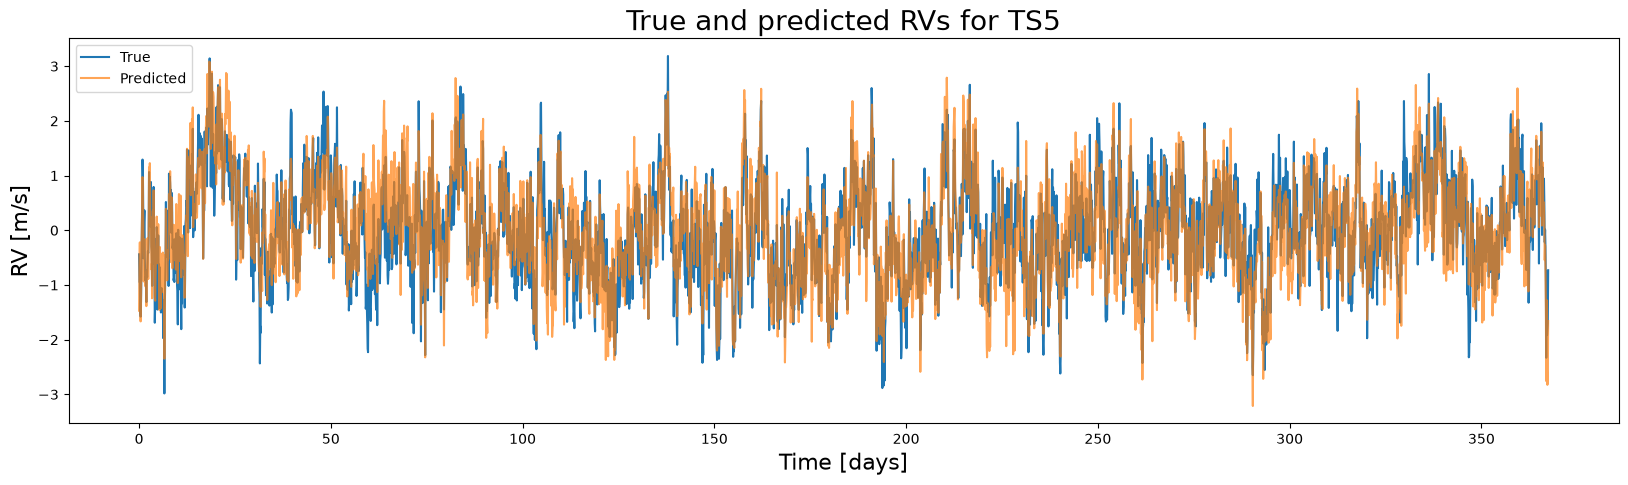

In [23]:
# Show an example of True and Predicted
i = 5
rv_true_i = rv[i][:-chunks_rest]
rv_pred_i = rv_pred[i].flatten()

fig, ax = plt.subplots(figsize=(20, 5))
ax.set_title(f'True and predicted RVs for TS{i}', size=20)

ax.plot(times_short, rv_true_i, label='True')
ax.plot(times_short, rv_pred_i, alpha=.7, label='Predicted')

ax.set_xlabel('Time [days]', size=16)
ax.set_ylabel('RV [m/s]', size=16)

ax.legend()

plt.show()

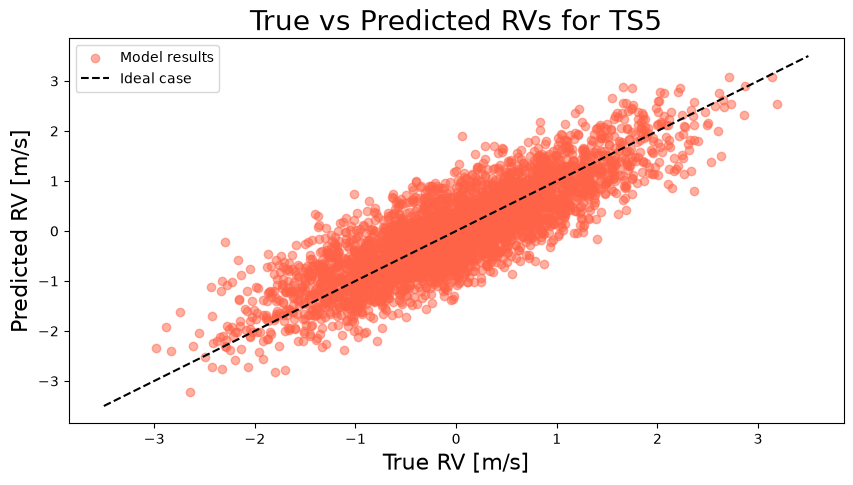

In [24]:
# show an example of Pred vs True
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_title(f'True vs Predicted RVs for TS{i}', size=20)

ax.scatter(rv_true_i, rv_pred_i, color='tomato', alpha=.5, label='Model results')
ax.plot([-3.5, 3.5], [-3.5, 3.5], linestyle='--', color='k', label='Ideal case')

ax.set_xlabel('True RV [m/s]', size=16)
ax.set_ylabel('Predicted RV [m/s]', size=16)

ax.legend()

plt.show()

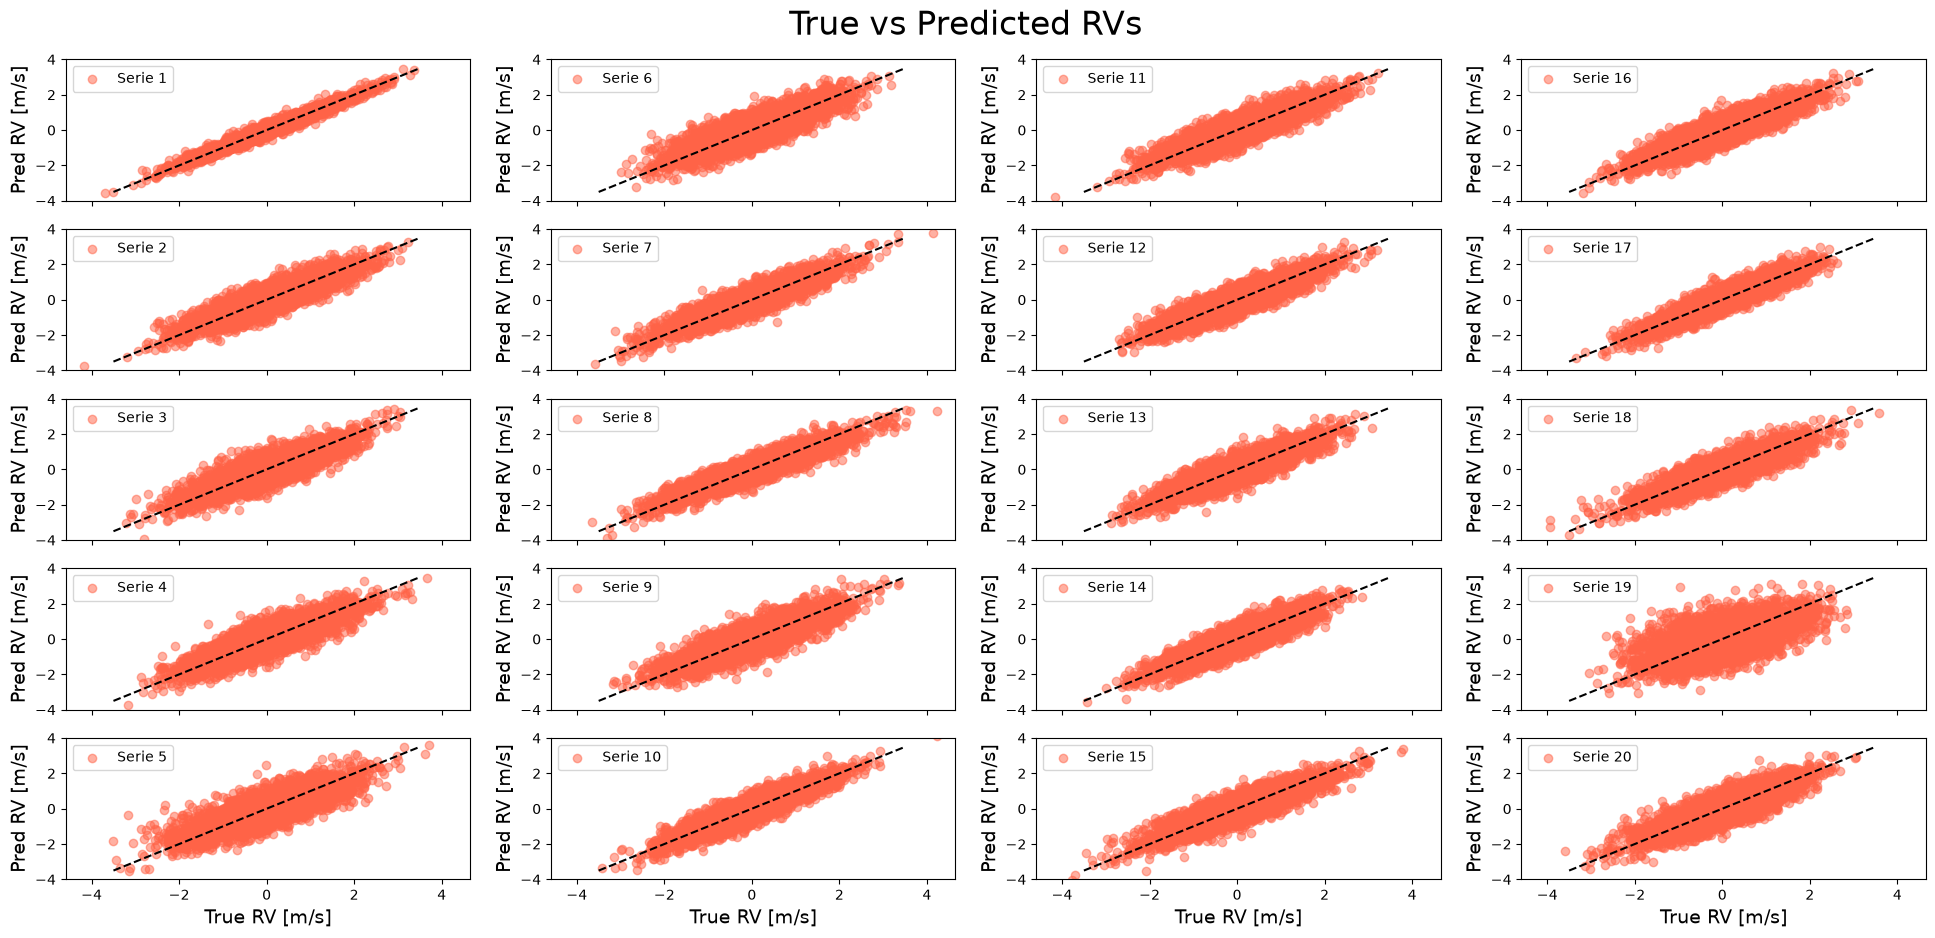

In [33]:
# plot Pred vs True for each TS
rows = 5
cols = 4
fig, axs = plt.subplots(rows, cols, figsize=(24, 10), sharex=True)
fig.suptitle('True vs Predicted RVs', size=24)

r = 0  # row counter
k = -1  # column counter

for i in range(TS):  # iterate over the N_files time series of spectra

    if i % rows == 0:  # if the column is filled, advance to the next one
        k += 1  # advance to the next column
        r = 0  # reset row

    if (i + 1) % rows == 0:  # set label only in the last row of each column
        axs[r][k].set_xlabel('True RV [m/s]', size=14)
    
    axs[r][k].scatter(rv[i][:-chunks_rest], rv_pred[i].flatten(), color='tomato', alpha=.5, label=f'Serie {i+1}')
    axs[r][k].plot([-3.5, 3.5], [-3.5, 3.5], linestyle='--', color='k')
    axs[r][k].set_ylim(-4, 4)
    axs[r][k].set_ylabel('Pred RV [m/s]', size=14)
    axs[r][k].legend()
    r += 1  # advance to the next row

plt.subplots_adjust(top=.93)
plt.show()